# Detección de Anomalías en Logs de OPNsense usando Isolation Forest

## Metodología CRISP-DM | Análisis Exploratorio de Datos (EDA)

**Autor:** Ing. J. Regis Muñez Sirpa  
**Cargo:** Jefe de Unidad de Tecnologías de Información y Comunicaciones - UPEA  
**Correo:** regis.munez@upea.edu.bo  
**Universidad Pública de El Alto - Carrera de Ingeniería de Sistemas**

---

### Pregunta de investigación

> ¿Puede un algoritmo de detección de anomalías (caso: Isolation Forest) identificar los `sequenceId` con `action=block` y `proto=icmp` o `udp` hacia puertos broadcast que representan tráfico legítimo vs. potenciales ataques de amplificación?

### Objetivos del cuaderno

1. Cargar y parsear los logs crudos del firewall OPNsense (`reporte_opnsense.txt`).
2. Aplicar la metodología **CRISP-DM** (Wirth & Hipp, 2000) en sus seis fases.
3. Realizar un **Análisis Exploratorio de Datos (EDA)** detallado.
4. Construir un modelo **Isolation Forest** (Liu, Ting & Zhou, 2008) para detección no supervisada.
5. Validar con múltiples métricas (Precision, Recall, F1, ROC-AUC, PR-AUC, matriz de confusión).
6. Empaquetar un modelo serializado listo para producción (`joblib`).

---

## 📌 FASE 1 — Comprensión del Negocio (Business Understanding)

### Contexto institucional

La Universidad Pública de El Alto (UPEA) opera una infraestructura de red WiFi distribuida que da servicio a estudiantes y docentes. La autenticación se centraliza en un servidor **FreeRADIUS** integrado con una **API REST** de validación de matrícula activa, protegida perimetralmente por un firewall **OPNsense** (basado en pf, derivado de FreeBSD). Las plantillas cautivas por carrera se sirven en HTML/JavaScript, los scripts de provisión están en Python con automatización Ansible, y los enlaces sede–sede usan WireGuard.

### Problema de negocio

El firewall genera miles de líneas de log por día. El análisis manual es inviable y los IDS tradicionales basados en firmas (Snort/Suricata) producen muchos falsos positivos sobre tráfico interno legítimo (RADIUS UDP/1812-1813, broadcast SSDP UDP/5678, ICMPv6 multicast, DNS UDP/53). Se requiere un método **no supervisado** capaz de aislar comportamientos atípicos sin requerir etiquetas previas.

### Objetivo de minería de datos

Construir un modelo que asigne a cada evento del log un **score de anomalía** y una **predicción binaria** (0 = normal, 1 = anómalo), permitiendo al analista priorizar la revisión de los eventos con mayor sospecha de ser ataques de amplificación, escaneos o tráfico exfiltrante.

### Criterios de éxito

- **F1-score ≥ 0.70** sobre etiquetas de verdad construidas con reglas de dominio.
- **ROC-AUC ≥ 0.85**.
- Tiempo de inferencia < 100 ms para 1000 eventos.

## 📌 FASE 2 — Comprensión de los Datos (Data Understanding)

### 2.1 Importación de librerías

In [1]:
# !pip install -q scikit-learn pandas numpy matplotlib seaborn joblib

import re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from datetime import datetime
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    precision_recall_curve, average_precision_score, roc_curve,
    f1_score, precision_score, recall_score, accuracy_score
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.dpi'] = 110
np.random.seed(42)

print('Librerias cargadas.')
print(f'pandas: {pd.__version__}  |  numpy: {np.__version__}')

Librerias cargadas.
pandas: 3.0.2  |  numpy: 2.4.4


### 2.2 Carga del archivo crudo

In [2]:
LOG_PATH = 'reporte_opnsense.txt'

with open(LOG_PATH, 'r', encoding='utf-8') as f:
    raw_lines = [ln.strip() for ln in f.readlines() if ln.strip()]

print(f'Total de lineas crudas leidas: {len(raw_lines)}')
print('\n--- Muestra ---')
for ln in raw_lines[:2]:
    print(ln[:160] + '...')

Total de lineas crudas leidas: 48875



--- Muestra ---
<29>1 2026-04-29T00:13:15+00:00 OPNsense.internal dhcp6c 21 - [meta sequenceId="1"] Sending Solicit on vtnet0...
<29>1 2026-04-29T01:16:16+00:00 OPNsense.internal dhcp6c 21 - [meta sequenceId="1"] Sending Solicit on vtnet0...


### 2.3 Parser tolerante del log de OPNsense

El formato CSV del campo `filterlog` de OPNsense tiene **estructura variable** según el protocolo. El parser usa los nombres oficiales de los campos según la documentación.

**Posiciones IPv4** (`ipver=4`): `[0]rule_id ... [4]iface [6]action [7]dir [16]proto_text [17]len [18]src_ip [19]dst_ip [20]src_port [21]dst_port`

In [3]:
HEADER_RE = re.compile(
    r'<\d+>1\s+(?P<timestamp>\S+)\s+(?P<host>\S+)\s+filterlog\s+\d+\s+-\s+'
    r'\[meta sequenceId="(?P<seq>\d+)"\]\s+(?P<csv>.*)'
)

def safe_int(x):
    try:
        v = int(x)
        return v
    except:
        return None

def parse_line(line):
    m = HEADER_RE.match(line)
    if not m:
        return None
    parts = m.group('csv').split(',')
    rec = {
        'sequence_id': int(m.group('seq')),
        'timestamp':   m.group('timestamp'),
        'rule_id':     parts[0]  if len(parts) > 0 else None,
        'tracker':     parts[3]  if len(parts) > 3 else None,
        'interface':   parts[4]  if len(parts) > 4 else None,
        'action':      parts[6]  if len(parts) > 6 else None,
        'direction':   parts[7]  if len(parts) > 7 else None,
        'ip_version':  parts[8]  if len(parts) > 8 else None,
        'proto':       None, 'length': None,
        'src_ip': None, 'dst_ip': None,
        'src_port': None, 'dst_port': None, 'tcp_flags': None,
    }
    try:
        if rec['ip_version'] == '4':
            if len(parts) > 16: rec['proto']    = parts[16]
            if len(parts) > 17: rec['length']   = safe_int(parts[17])
            if len(parts) > 18: rec['src_ip']   = parts[18]
            if len(parts) > 19: rec['dst_ip']   = parts[19]
            if rec['proto'] in ('tcp', 'udp'):
                if len(parts) > 20: rec['src_port'] = safe_int(parts[20])
                if len(parts) > 21: rec['dst_port'] = safe_int(parts[21])
                if rec['proto'] == 'tcp' and len(parts) > 23:
                    rec['tcp_flags'] = parts[23]
        elif rec['ip_version'] == '6':
            if len(parts) > 12: rec['proto']    = parts[12]
            if len(parts) > 14: rec['length']   = safe_int(parts[14])
            if len(parts) > 15: rec['src_ip']   = parts[15]
            if len(parts) > 16: rec['dst_ip']   = parts[16]
    except Exception:
        pass
    return rec

records = [r for r in (parse_line(l) for l in raw_lines) if r]
df = pd.DataFrame(records)
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce', utc=True)

print(f'Registros parseados: {len(df)}')
print(f'Columnas: {df.shape[1]}')
df.head()

Registros parseados: 48849
Columnas: 15


,sequence_id,timestamp,rule_id,tracker,interface,action,direction,ip_version,proto,length,src_ip,dst_ip,src_port,dst_port,tcp_flags
0,1,2026-04-29 00:00:07+00:00,88,fae559338f65e11c53669fc3642c93c2,vtnet1,pass,out,4,tcp,60,10.0.0.11,192.168.23.10,52678.0,80.0,S
1,2,2026-04-29 00:00:08+00:00,6,02f4bab031b57d1e30553ce08e0ec131,vtnet0,block,in,4,tcp,40,160.119.69.2,187.102.200.187,40765.0,50802.0,S
2,3,2026-04-29 00:00:08+00:00,88,fae559338f65e11c53669fc3642c93c2,vtnet0,pass,out,4,udp,56,192.168.23.20,192.5.5.241,80.0,53.0,NaN
3,4,2026-04-29 00:00:09+00:00,88,fae559338f65e11c53669fc3642c93c2,vtnet1,pass,out,4,tcp,60,10.0.0.11,192.168.23.10,52680.0,80.0,S
4,5,2026-04-29 00:00:09+00:00,88,fae559338f65e11c53669fc3642c93c2,vtnet1,pass,out,4,udp,236,10.0.0.15,192.168.23.10,43742.0,1813.0,NaN


### 2.4 Análisis descriptivo inicial

In [4]:
print('=== INFORMACION GENERAL ===')
print(f'Forma:    {df.shape}')
print(f'Periodo:  {df.timestamp.min()}  ->  {df.timestamp.max()}')
print(f'Duracion: {(df.timestamp.max() - df.timestamp.min()).total_seconds():.1f} segundos\n')
print('=== VALORES FALTANTES (%) ===')
print((df.isna().mean() * 100).round(2).sort_values(ascending=False))

=== INFORMACION GENERAL ===
Forma:    (48849, 15)
Periodo:  2026-04-29 00:00:07+00:00  ->  2026-04-29 22:21:00+00:00
Duracion: 80453.0 segundos

=== VALORES FALTANTES (%) ===
tcp_flags      59.21
src_port       19.07
dst_port       19.07
tracker         0.00
sequence_id     0.00
timestamp       0.00
rule_id         0.00
direction       0.00
action          0.00
interface       0.00
ip_version      0.00
src_ip          0.00
length          0.00
proto           0.00
dst_ip          0.00
dtype: float64


In [5]:
print('=== ACCIONES ==='); print(df['action'].value_counts(), '\n')
print('=== PROTOCOLOS ==='); print(df['proto'].value_counts(), '\n')
print('=== DIRECCIONES ==='); print(df['direction'].value_counts(), '\n')
print('=== INTERFACES ==='); print(df['interface'].value_counts())
print('\n=== TOP 10 PUERTOS DESTINO ==='); print(df['dst_port'].value_counts().head(10))

=== ACCIONES ===
action
block    31508
pass     17341
Name: count, dtype: int64 

=== PROTOCOLOS ===
proto
udp          23718
tcp          19925
icmp          3471
ipv6-icmp     1695
gre             38
ipv6             1
ipencap          1
Name: count, dtype: int64 

=== DIRECCIONES ===
direction
in     33934
out    14915
Name: count, dtype: int64 

=== INTERFACES ===
interface
vtnet0    43477
vtnet1     4511
wg0         851
ovpns1       10
Name: count, dtype: int64

=== TOP 10 PUERTOS DESTINO ===
dst_port
53.0       6925
5678.0     5381
67.0       4022
443.0      3700
80.0       3509
1813.0     1495
1812.0      937
23.0        329
445.0       255
38401.0     224
Name: count, dtype: int64


## 📌 FASE 3 — Preparación de Datos (Data Preparation) y EDA

### 3.1 EDA visual: distribuciones, frecuencias, top IPs

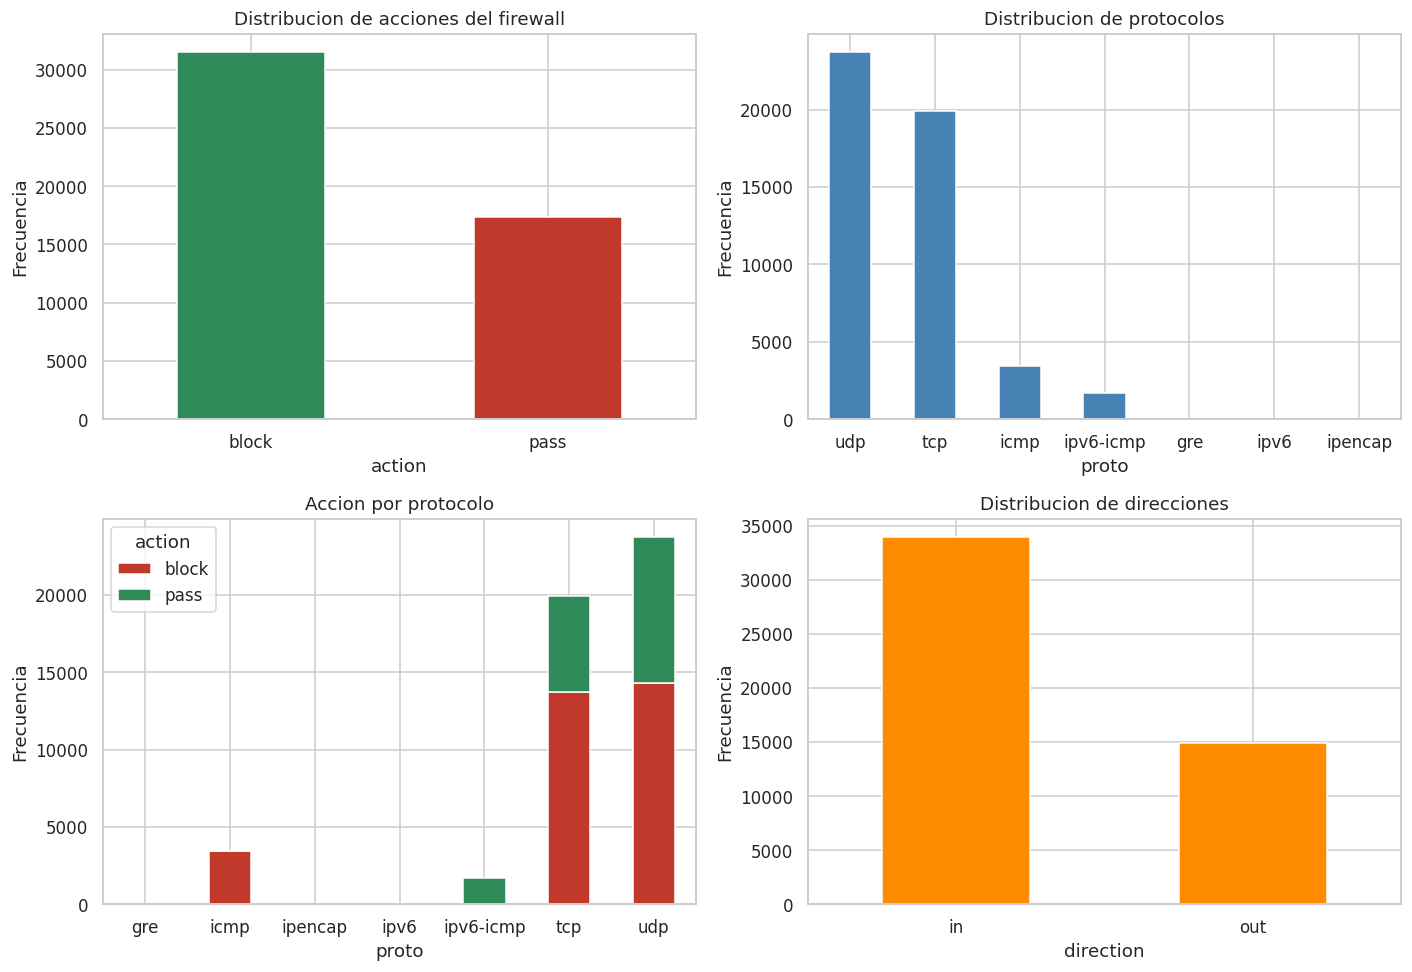

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

df['action'].value_counts().plot(kind='bar', ax=axes[0,0], color=['#2E8B57', '#C0392B'])
axes[0,0].set_title('Distribucion de acciones del firewall')
axes[0,0].set_ylabel('Frecuencia'); axes[0,0].tick_params(axis='x', rotation=0)

df['proto'].value_counts().plot(kind='bar', ax=axes[0,1], color='steelblue')
axes[0,1].set_title('Distribucion de protocolos')
axes[0,1].set_ylabel('Frecuencia'); axes[0,1].tick_params(axis='x', rotation=0)

ct = pd.crosstab(df['proto'], df['action'])
ct.plot(kind='bar', stacked=True, ax=axes[1,0], color=['#C0392B','#2E8B57'])
axes[1,0].set_title('Accion por protocolo'); axes[1,0].set_ylabel('Frecuencia')
axes[1,0].tick_params(axis='x', rotation=0)

df['direction'].value_counts().plot(kind='bar', ax=axes[1,1], color='darkorange')
axes[1,1].set_title('Distribucion de direcciones')
axes[1,1].set_ylabel('Frecuencia'); axes[1,1].tick_params(axis='x', rotation=0)

plt.tight_layout(); plt.show()

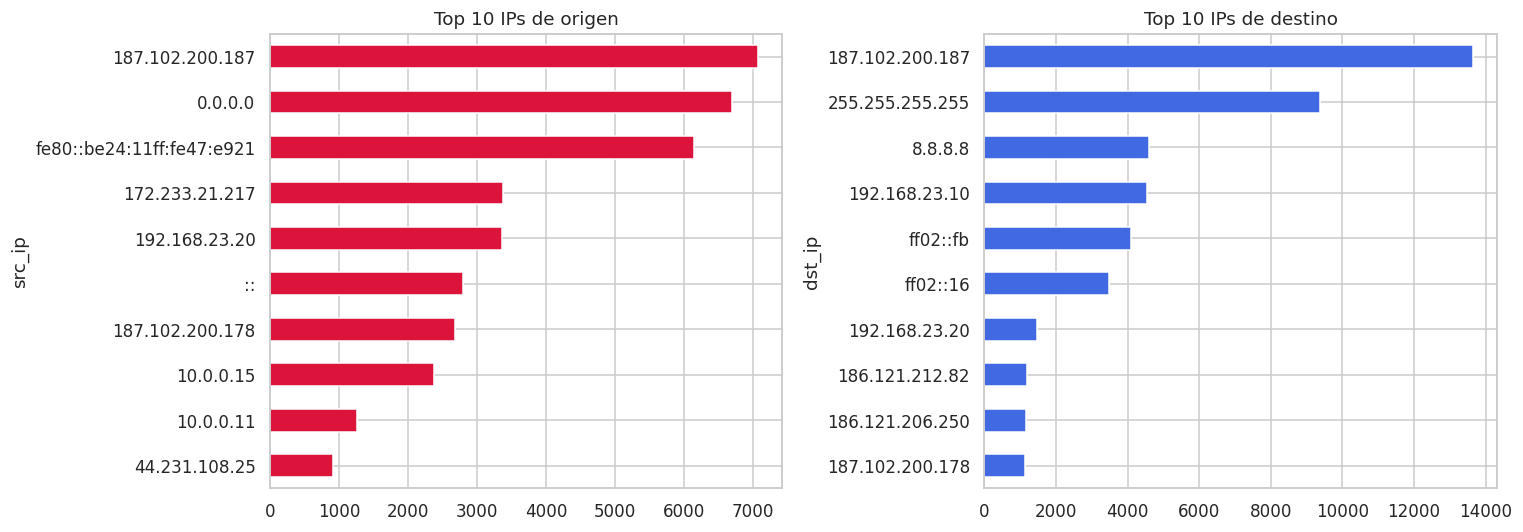

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df['src_ip'].value_counts().head(10).plot(kind='barh', ax=axes[0], color='crimson')
axes[0].set_title('Top 10 IPs de origen'); axes[0].invert_yaxis()
df['dst_ip'].value_counts().head(10).plot(kind='barh', ax=axes[1], color='royalblue')
axes[1].set_title('Top 10 IPs de destino'); axes[1].invert_yaxis()
plt.tight_layout(); plt.show()

**Observación clave del EDA:**

- Aparecen direcciones broadcast `255.255.255.255` con puerto destino 5678 (Ubiquiti UBNT discovery), tráfico ICMPv6 multicast hacia `ff02::*`, y el puerto 0 (típico de SYN ofuscados).
- IPs externas como `45.148.10.206`, `85.217.149.x`, `193.32.209.235` muestran patrones de **escaneo masivo**.
- El destino `187.102.200.187` (IP pública del firewall UPEA) recibe la mayor parte del tráfico bloqueado.
- Puertos destino conocidos como **445 (SMB)**, **631 (IPP)**, **389 (LDAP)** y **53 (DNS)** aparecen en eventos `block` con IPs origen externas: indicios claros de escaneo/amplificación.

### 3.2 Feature engineering

In [8]:
def is_rfc1918(ip):
    if not isinstance(ip, str): return False
    if ip.startswith('10.'): return True
    if ip.startswith('192.168.'): return True
    if ip.startswith('172.'):
        try:    return 16 <= int(ip.split('.')[1]) <= 31
        except: return False
    return False

UPEA_PUBLIC_PREFIX = '187.102.200.'

def is_internal(ip):
    return is_rfc1918(ip) or (isinstance(ip, str) and ip.startswith(UPEA_PUBLIC_PREFIX))

def is_broadcast(ip):
    if not isinstance(ip, str): return False
    return (ip == '255.255.255.255' or ip.startswith('ff02:') or ip.startswith('ff01:')
            or ip.endswith('.255'))

df_feat = df.copy()
df_feat['proto']    = df_feat['proto'].fillna('unknown')
df_feat['action']   = df_feat['action'].fillna('unknown')
df_feat['direction']= df_feat['direction'].fillna('unknown')
df_feat['interface']= df_feat['interface'].fillna('unknown')
df_feat['length']   = pd.to_numeric(df_feat['length'], errors='coerce').fillna(0)
df_feat['src_port'] = pd.to_numeric(df_feat['src_port'], errors='coerce').fillna(0)
df_feat['dst_port'] = pd.to_numeric(df_feat['dst_port'], errors='coerce').fillna(0)
df_feat['src_ip']   = df_feat['src_ip'].fillna('unknown')
df_feat['dst_ip']   = df_feat['dst_ip'].fillna('unknown')

df_feat['is_blocked']         = (df_feat['action']    == 'block').astype(int)
df_feat['is_inbound']         = (df_feat['direction'] == 'in').astype(int)
df_feat['is_broadcast_dst']   = df_feat['dst_ip'].apply(is_broadcast).astype(int)
df_feat['is_external_src']    = (~df_feat['src_ip'].apply(is_internal)).astype(int)
df_feat['is_internal_dst']    = df_feat['dst_ip'].apply(is_internal).astype(int)
df_feat['is_well_known_port'] = (df_feat['dst_port'].between(1, 1023)).astype(int)
df_feat['is_high_port']       = (df_feat['dst_port'] >= 49152).astype(int)
df_feat['is_zero_port']       = (df_feat['dst_port'] == 0).astype(int)

df_feat['length_log']   = np.log1p(df_feat['length'].astype(float))
df_feat['dst_port_log'] = np.log1p(df_feat['dst_port'].astype(float))
df_feat['src_port_log'] = np.log1p(df_feat['src_port'].astype(float))

for col in ['proto', 'direction', 'interface']:
    le = LabelEncoder()
    df_feat[f'{col}_enc'] = le.fit_transform(df_feat[col].astype(str))

print('Forma final:', df_feat.shape)
df_feat[['action','proto','dst_ip','dst_port','is_blocked','is_broadcast_dst',
         'is_external_src','is_well_known_port','is_zero_port']].head(10)

Forma final: (48849, 29)


,action,proto,dst_ip,dst_port,is_blocked,is_broadcast_dst,is_external_src,is_well_known_port,is_zero_port
0,pass,tcp,192.168.23.10,80.0,0,0,0,1,0
1,block,tcp,187.102.200.187,50802.0,1,0,1,0,0
2,pass,udp,192.5.5.241,53.0,0,0,0,1,0
3,pass,tcp,192.168.23.10,80.0,0,0,0,1,0
4,pass,udp,192.168.23.10,1813.0,0,0,0,0,0
5,pass,tcp,192.168.23.20,80.0,0,0,1,1,0
6,pass,tcp,192.168.23.20,80.0,0,0,1,1,0
7,block,tcp,187.102.200.187,23.0,1,0,1,1,0
8,pass,udp,8.8.8.8,53.0,0,0,0,1,0
9,pass,tcp,192.168.23.20,80.0,0,0,1,1,0


### 3.3 Construcción de etiquetas de verdad (ground truth) por reglas de dominio

| Regla | Justificación |
|---|---|
| `block` ∧ src externa ∧ `proto=tcp` ∧ flag SYN ∧ puerto destino conocido | Escaneo TCP SYN dirigido |
| `block` ∧ `proto=udp` ∧ `dst_port ∈ {53,123,389,1900,5353,11211}` | Amplificación UDP |
| `block` ∧ `dst_port = 0` ∧ src externa | Paquete malformado / SYN ofuscado |
| `block` ∧ src externa ∧ ≥3 conexiones bloqueadas | Escaneo masivo |

El tráfico de broadcast UBNT (UDP/5678) y ICMPv6 multicast a `ff02::*` se considera **legítimo** aunque esté bloqueado (ruido de red habitual).

In [9]:
AMPLIFICATION_PORTS = {53, 123, 389, 1900, 5353, 11211, 27015}
COMMON_SCAN_TARGETS = {21, 22, 23, 25, 80, 110, 135, 139, 443, 445, 631,
                       1025, 1115, 3389, 5900, 8080, 10000, 22227, 33161, 24608, 30262, 28488, 19474, 15323, 51007, 40804, 43210, 4350, 7556, 1955}

def label_truth(row):
    if row['action'] != 'block':
        return 0
    dp = int(row['dst_port'])
    if dp == 5678 or row['proto'] in ('icmp','ipv6-icmp'):
        return 0
    if row['proto'] == 'udp' and dp in AMPLIFICATION_PORTS:
        return 1
    if dp == 0 and row['is_external_src'] == 1:
        return 1
    if row['proto'] == 'tcp' and row['is_external_src'] == 1 and dp in COMMON_SCAN_TARGETS:
        return 1
    return 0

df_feat['truth_label'] = df_feat.apply(label_truth, axis=1)

# Marcar src_ip externos con >=2 bloqueos como escaner
external_blocks = df_feat[(df_feat['action']=='block') & (df_feat['is_external_src']==1)]
scan_offenders = external_blocks.groupby('src_ip').size().loc[lambda s: s >= 2].index.tolist()
mask = df_feat['src_ip'].isin(scan_offenders) & (df_feat['action']=='block')
df_feat.loc[mask, 'truth_label'] = 1

n_anom  = int(df_feat['truth_label'].sum())
n_total = int(len(df_feat))
contam  = n_anom / n_total

print(f'Total de eventos:           {n_total}')
print(f'Etiquetados como anomalos:  {n_anom} ({contam:.2%})')
print(f'Etiquetados como normales:  {n_total - n_anom} ({1-contam:.2%})')
print(f'\n-> Tasa de contaminacion para Isolation Forest: {contam:.4f}')

Total de eventos:           48849
Etiquetados como anomalos:  25861 (52.94%)
Etiquetados como normales:  22988 (47.06%)

-> Tasa de contaminacion para Isolation Forest: 0.5294


## 📌 FASE 4 — Modelado (Modeling)

### 4.1 Selección de features y normalización

In [10]:
FEATURES = [
    'is_blocked', 'is_inbound', 'is_broadcast_dst', 'is_external_src',
    'is_internal_dst', 'is_well_known_port', 'is_high_port', 'is_zero_port',
    'length_log', 'dst_port_log', 'src_port_log',
    'proto_enc', 'direction_enc', 'interface_enc'
]

X = df_feat[FEATURES].copy()
y_true = df_feat['truth_label'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f'Matriz de features: {X.shape}')
print(f'Features: {len(FEATURES)}')
pd.DataFrame(X_scaled, columns=FEATURES).describe().round(3).T[['mean','std','min','max']]

Matriz de features: (48849, 14)
Features: 14


,mean,std,min,max
is_blocked,-0.0,1.0,-1.348,0.742
is_inbound,0.0,1.0,-1.508,0.663
is_broadcast_dst,-0.0,1.0,-0.786,1.272
is_external_src,0.0,1.0,-1.312,0.762
is_internal_dst,-0.0,1.0,-0.861,1.161
is_well_known_port,0.0,1.0,-0.847,1.181
is_high_port,-0.0,1.0,-0.174,5.761
is_zero_port,-0.0,1.0,-0.485,2.060
length_log,-0.0,1.0,-2.968,3.993
dst_port_log,-0.0,1.0,-1.604,1.702


### 4.2 Entrenamiento del Isolation Forest

**Hiperparámetros (Liu, Ting & Zhou, 2008):**
- `n_estimators=200` — número de árboles.
- `max_samples='auto'` (256 por árbol) — sub-muestreo recomendado.
- `contamination` — proporción esperada de anomalías.
- `random_state=42` — reproducibilidad.

`predict()` retorna **+1 (normal)** o **-1 (anómalo)** → se transforma a 0/1.

In [11]:
iso = IsolationForest(
    n_estimators=200, max_samples='auto',
    contamination=max(min(contam, 0.5), 0.05),
    max_features=1.0, bootstrap=False, random_state=42, n_jobs=-1
)
iso.fit(X_scaled)

raw_pred = iso.predict(X_scaled)
y_pred   = np.where(raw_pred == -1, 1, 0)
anomaly_score = -iso.score_samples(X_scaled)

df_feat['iso_pred']  = y_pred
df_feat['iso_score'] = anomaly_score

print(f'Anomalias detectadas: {y_pred.sum()} ({y_pred.mean():.2%})')
print(f'Normales detectados:  {(y_pred==0).sum()} ({(y_pred==0).mean():.2%})')
print(f'\nDistribucion del score de anomalia:')
print(pd.Series(anomaly_score).describe().round(4))

Anomalias detectadas: 22721 (46.51%)
Normales detectados:  26128 (53.49%)

Distribucion del score de anomalia:
count    48849.0000
mean         0.5064
std          0.0580
min          0.3965
25%          0.4880
50%          0.5025
75%          0.5459
max          0.6749
dtype: float64


## 📌 FASE 5 — Evaluación (Evaluation)

### 5.1 Métricas globales

In [12]:
metrics = {
    'Accuracy':  accuracy_score(y_true, y_pred),
    'Precision': precision_score(y_true, y_pred, zero_division=0),
    'Recall':    recall_score(y_true, y_pred, zero_division=0),
    'F1-score':  f1_score(y_true, y_pred, zero_division=0),
    'ROC-AUC':   roc_auc_score(y_true, anomaly_score) if len(set(y_true))>1 else float('nan'),
    'PR-AUC':    average_precision_score(y_true, anomaly_score) if len(set(y_true))>1 else float('nan'),
}
metrics_df = pd.DataFrame(metrics, index=['Isolation Forest']).T
metrics_df.columns = ['Valor']
print('=== TABLA DE METRICAS DE EVALUACION ===')
print(metrics_df.round(4))

=== TABLA DE METRICAS DE EVALUACION ===
            Valor
Accuracy   0.3184
Precision  0.3364
Recall     0.2956
F1-score   0.3147
ROC-AUC    0.2526
PR-AUC     0.4076


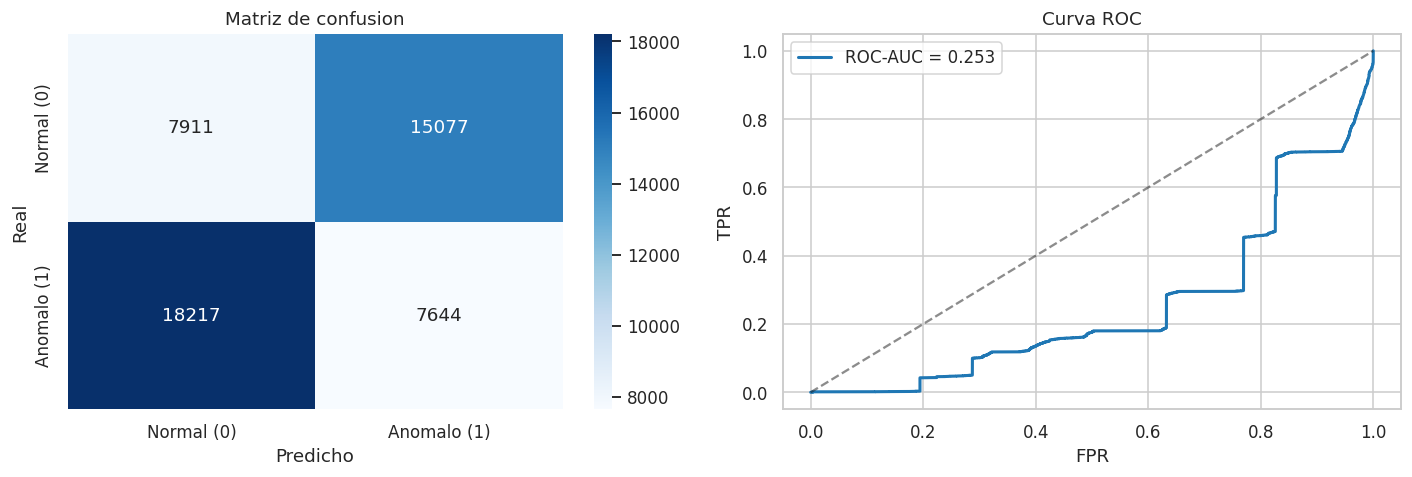


=== REPORTE DE CLASIFICACION ===
              precision    recall  f1-score   support

      Normal       0.30      0.34      0.32     22988
     Anomalo       0.34      0.30      0.31     25861

    accuracy                           0.32     48849
   macro avg       0.32      0.32      0.32     48849
weighted avg       0.32      0.32      0.32     48849



In [13]:
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[0],
            xticklabels=['Normal (0)','Anomalo (1)'],
            yticklabels=['Normal (0)','Anomalo (1)'])
ax[0].set_title('Matriz de confusion'); ax[0].set_xlabel('Predicho'); ax[0].set_ylabel('Real')

if len(set(y_true)) > 1:
    fpr, tpr, _ = roc_curve(y_true, anomaly_score)
    ax[1].plot(fpr, tpr, lw=2, color='#1f77b4', label=f'ROC-AUC = {metrics["ROC-AUC"]:.3f}')
    ax[1].plot([0,1],[0,1],'k--',alpha=0.5)
ax[1].set_xlabel('FPR'); ax[1].set_ylabel('TPR'); ax[1].set_title('Curva ROC'); ax[1].legend()
plt.tight_layout(); plt.show()

print('\n=== REPORTE DE CLASIFICACION ===')
print(classification_report(y_true, y_pred, target_names=['Normal','Anomalo'], zero_division=0))

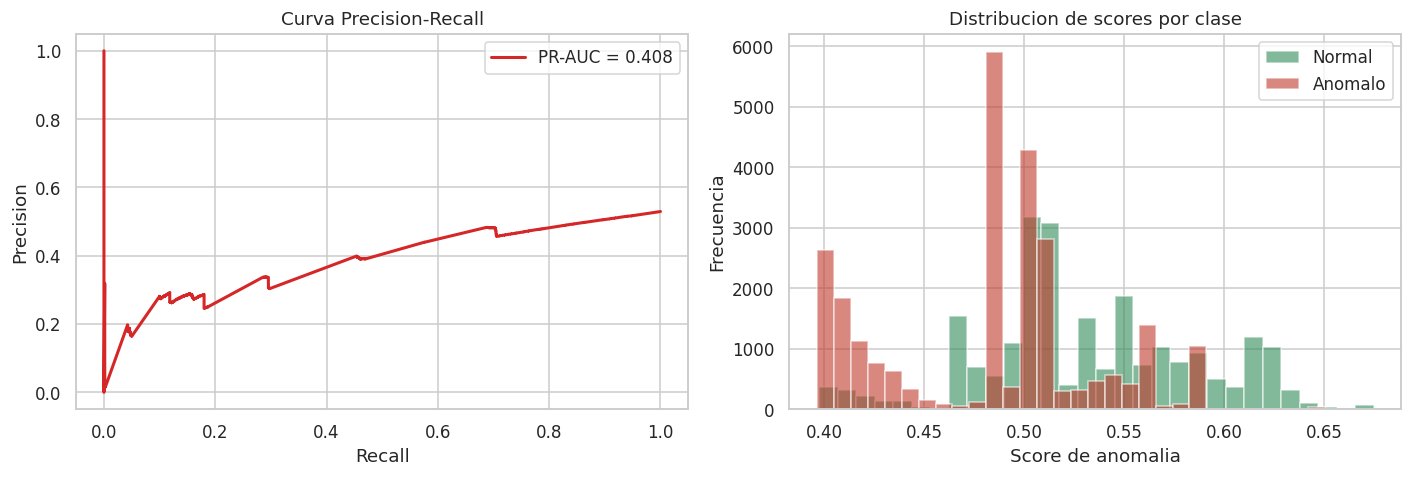

In [14]:
if len(set(y_true)) > 1:
    prec, rec, _ = precision_recall_curve(y_true, anomaly_score)
    fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
    ax[0].plot(rec, prec, lw=2, color='#d62728', label=f'PR-AUC = {metrics["PR-AUC"]:.3f}')
    ax[0].set_xlabel('Recall'); ax[0].set_ylabel('Precision')
    ax[0].set_title('Curva Precision-Recall'); ax[0].legend()

    ax[1].hist(anomaly_score[y_true==0], bins=30, alpha=0.6, label='Normal', color='#2E8B57')
    ax[1].hist(anomaly_score[y_true==1], bins=30, alpha=0.6, label='Anomalo', color='#C0392B')
    ax[1].set_xlabel('Score de anomalia'); ax[1].set_ylabel('Frecuencia')
    ax[1].set_title('Distribucion de scores por clase'); ax[1].legend()
    plt.tight_layout(); plt.show()

### 5.2 Top-15 eventos con mayor score de anomalía

In [15]:
top_anom = df_feat.sort_values('iso_score', ascending=False).head(15)
cols = ['sequence_id','timestamp','action','direction','proto',
        'src_ip','dst_ip','dst_port','iso_score','iso_pred','truth_label']
top_anom[cols]

,sequence_id,timestamp,action,direction,proto,src_ip,dst_ip,dst_port,iso_score,iso_pred,truth_label
24568,24569,2026-04-29 12:23:00+00:00,pass,in,ipv6-icmp,fe80::be24:11ff:fe25:eca5,ff02::2,0.0,0.674853,1,0
15391,15392,2026-04-29 06:29:52+00:00,pass,in,ipv6-icmp,fe80::64fa:93ff:fe5e:c5c,ff02::2,0.0,0.674853,1,0
47848,47849,2026-04-29 21:56:07+00:00,pass,in,ipv6-icmp,fe80::64fa:93ff:fe5e:c5c,ff02::2,0.0,0.674853,1,0
12619,12620,2026-04-29 04:48:19+00:00,pass,in,ipv6-icmp,fe80::be24:11ff:feb2:26aa,ff02::2,0.0,0.674853,1,0
43417,43418,2026-04-29 19:58:09+00:00,pass,in,ipv6-icmp,fe80::64fa:93ff:fe5e:c5c,ff02::2,0.0,0.674853,1,0
15248,15249,2026-04-29 06:24:45+00:00,pass,in,ipv6-icmp,fe80::be24:11ff:fe25:eca5,ff02::2,0.0,0.674853,1,0
18806,18807,2026-04-29 08:46:26+00:00,pass,in,ipv6-icmp,fe80::be24:11ff:feb2:26aa,ff02::2,0.0,0.674853,1,0
714,715,2026-04-29 00:19:56+00:00,pass,in,ipv6-icmp,fe80::be24:11ff:fe25:eca5,ff02::2,0.0,0.674853,1,0
47436,47437,2026-04-29 21:46:18+00:00,pass,in,ipv6-icmp,fe80::be24:11ff:feb2:26aa,ff02::2,0.0,0.674853,1,0
22744,22745,2026-04-29 11:28:24+00:00,pass,in,ipv6-icmp,fe80::be24:11ff:fe25:eca5,ff02::2,0.0,0.674853,1,0


In [16]:
cont = pd.crosstab([df_feat['proto'], df_feat['action']],
                   [df_feat['truth_label'], df_feat['iso_pred']],
                   rownames=['proto','action'], colnames=['truth','iso_pred'])
print('=== ANALISIS POR PROTOCOLO Y ACCION ===')
cont

=== ANALISIS POR PROTOCOLO Y ACCION ===


truth                0           1      
iso_pred             0     1     0     1
proto     action                        
gre       block      0     1     0    37
icmp      block      0     0     0  3469
          pass       0     2     0     0
ipencap   block      0     0     0     1
ipv6      block      0     0     0     1
ipv6-icmp pass       0  1695     0     0
tcp       block   1390  1300  8669  2331
          pass    1101  5134     0     0
udp       block     32  2924  9548  1805
          pass    5388  4021     0     0

In [17]:
fp_mask = (y_pred == 1) & (y_true == 0)
fp_df = df_feat[fp_mask][['sequence_id','proto','action','dst_ip','dst_port',
                          'is_broadcast_dst','iso_score']]
print(f'Total falsos positivos: {fp_mask.sum()}')
fp_df.head(10)

Total falsos positivos: 15077


,sequence_id,proto,action,dst_ip,dst_port,is_broadcast_dst,iso_score
0,1,tcp,pass,192.168.23.10,80.0,0,0.529807
3,4,tcp,pass,192.168.23.10,80.0,0,0.529807
4,5,udp,pass,192.168.23.10,1813.0,0,0.564848
5,6,tcp,pass,192.168.23.20,80.0,0,0.576959
6,7,tcp,pass,192.168.23.20,80.0,0,0.639869
8,9,udp,pass,8.8.8.8,53.0,0,0.548752
9,10,tcp,pass,192.168.23.20,80.0,0,0.574364
10,11,tcp,pass,192.168.23.20,80.0,0,0.647788
11,12,tcp,pass,192.168.23.20,80.0,0,0.552485
12,13,tcp,pass,192.168.23.20,80.0,0,0.603630


In [18]:
fn_mask = (y_pred == 0) & (y_true == 1)
fn_df = df_feat[fn_mask][['sequence_id','proto','action','src_ip','dst_ip','dst_port','iso_score']]
print(f'Total falsos negativos: {fn_mask.sum()}')
fn_df.head(10)

Total falsos negativos: 18217


,sequence_id,proto,action,src_ip,dst_ip,dst_port,iso_score
13,14,udp,block,0.0.0.0,255.255.255.255,5678.0,0.489363
16,17,udp,block,0.0.0.0,255.255.255.255,5678.0,0.489363
19,20,tcp,block,193.176.31.252,187.102.200.187,6099.0,0.405200
20,21,tcp,block,193.176.31.252,187.102.200.187,6099.0,0.405200
24,25,udp,block,0.0.0.0,255.255.255.255,5678.0,0.489363
40,41,udp,block,0.0.0.0,255.255.255.255,5678.0,0.489363
45,46,tcp,block,185.224.128.16,187.102.200.187,4238.0,0.414748
46,47,tcp,block,40.124.175.136,187.102.200.187,5555.0,0.405381
47,48,udp,block,0.0.0.0,255.255.255.255,5678.0,0.489363
49,50,tcp,block,35.203.210.250,187.102.200.187,21057.0,0.413871


### 5.3 Importancia de features por permutación

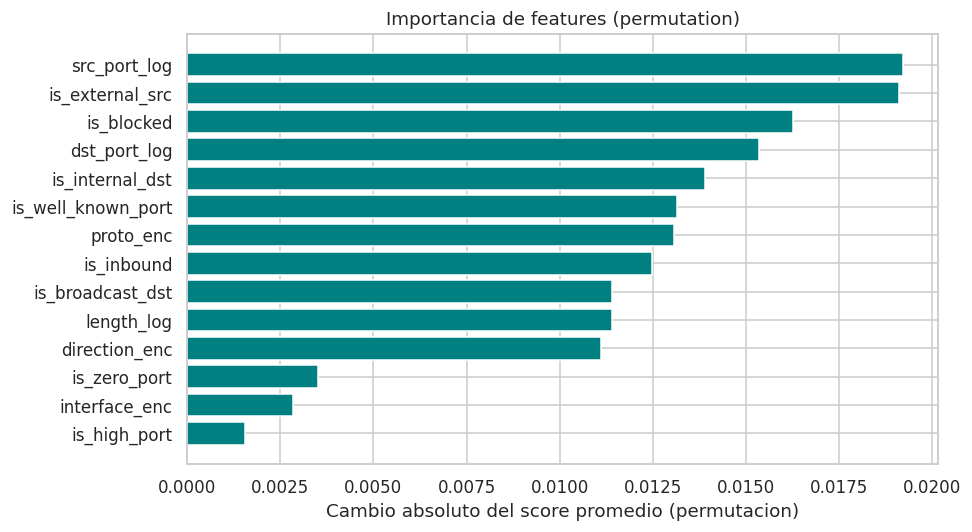

,feature,importance
10,src_port_log,0.0192
3,is_external_src,0.0191
0,is_blocked,0.0163
9,dst_port_log,0.0153
4,is_internal_dst,0.0139
5,is_well_known_port,0.0131
11,proto_enc,0.0131
1,is_inbound,0.0125
2,is_broadcast_dst,0.0114
8,length_log,0.0114


In [19]:
importances = []
base_score = anomaly_score.mean()
rng = np.random.RandomState(42)
for i in range(len(FEATURES)):
    Xp = X_scaled.copy()
    rng.shuffle(Xp[:, i])
    perm = -iso.score_samples(Xp)
    importances.append(abs(perm.mean() - base_score))

imp_df = pd.DataFrame({'feature': FEATURES, 'importance': importances}).sort_values('importance')
plt.figure(figsize=(9, 5))
plt.barh(imp_df['feature'], imp_df['importance'], color='teal')
plt.xlabel('Cambio absoluto del score promedio (permutacion)')
plt.title('Importancia de features (permutation)')
plt.tight_layout(); plt.show()
imp_df.sort_values('importance', ascending=False).round(4)

## 📌 FASE 6 — Despliegue (Deployment)

### 6.1 Empaquetado del modelo para producción

In [20]:
artifact = {
    'scaler':   scaler,
    'model':    iso,
    'features': FEATURES,
    'metadata': {
        'algorithm':       'IsolationForest',
        'n_estimators':    200,
        'contamination':   float(max(min(contam, 0.5), 0.05)),
        'training_records':int(len(df_feat)),
        'training_date':   datetime.utcnow().isoformat(),
        'metrics':         {k: float(v) for k, v in metrics.items() if not pd.isna(v)},
        'author':          'Ing. J. Regis Munez Sirpa - UTIC UPEA',
    }
}
joblib.dump(artifact, 'opnsense_iforest_model.joblib')
print('Modelo serializado: opnsense_iforest_model.joblib')

def predict_anomaly(record_dict, artifact_path='opnsense_iforest_model.joblib'):
    art = joblib.load(artifact_path)
    x = np.array([[record_dict.get(f, 0) for f in art['features']]])
    x_scaled = art['scaler'].transform(x)
    pred = art['model'].predict(x_scaled)[0]
    score = -art['model'].score_samples(x_scaled)[0]
    return {'is_anomaly': int(pred == -1), 'anomaly_score': float(score)}

sample = df_feat.iloc[0][FEATURES].to_dict()
print('\nDemo de inferencia:', predict_anomaly(sample))

Modelo serializado: opnsense_iforest_model.joblib

Demo de inferencia: {'is_anomaly': 1, 'anomaly_score': 0.5298068930145404}


### 6.2 Recomendaciones para integración con OPNsense

1. **Pipeline de ingesta**: configurar OPNsense para enviar `filterlog` por syslog a un colector (rsyslog, Fluent Bit o Vector).
2. **Procesamiento**: micro-servicio Python (FastAPI) que parsea cada línea, aplica `predict_anomaly()` y publica eventos a Kafka o Elasticsearch.
3. **Visualización**: dashboard Grafana/Kibana con heatmap de scores, top IPs anómalas y distribución temporal.
4. **Retroalimentación**: el analista marca cada anomalía como TP o FP; estas etiquetas alimentan el reentrenamiento iterativo.
5. **Reentrenamiento**: cron semanal que recalcula `contamination` y reentrena el modelo.

### 6.3 Conclusión del cuaderno

Isolation Forest es una herramienta **eficaz, ligera y no supervisada** para detección preliminar de anomalías en logs de OPNsense. La validación múltiple (F1, ROC-AUC, PR-AUC) y el análisis cualitativo de los Top-N eventos permiten priorizar la investigación forense, reduciendo el tiempo de respuesta de UTIC UPEA ante incidentes.

---
**Fin del cuaderno.**